# Data Preparation

This section loads and prepares the Bitcoin sentiment data and Hyperliquid trading data for analysis. It includes initial inspection of datasets.

In [56]:
import pandas as pd

sentiment = pd.read_csv("data/fear_greed.csv")
trades = pd.read_csv("data/hyperliquid.csv")

In [57]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [58]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [59]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [60]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [61]:
sentiment.columns


Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [62]:
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [63]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [64]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [65]:
sentiment.duplicated().sum()

np.int64(0)

In [66]:
trades.duplicated().sum()

np.int64(0)

In [67]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [68]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [69]:
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [70]:
trades.columns = trades.columns.str.strip().str.lower()

In [71]:
trades.columns = trades.columns.str.replace(' ', '_')

In [72]:
trades.columns

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')

In [73]:
trades['timestamp_ist'] = pd.to_datetime(
    trades['timestamp_ist'],
    dayfirst=True
)

In [74]:
trades['date'] = trades['timestamp_ist'].dt.date

In [75]:
trades[['timestamp_ist', 'date']].head()

,timestamp_ist,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [76]:
trades['date'] = pd.to_datetime(trades['date'])

In [77]:
trades['date'].dtype
sentiment['date'].dtype

dtype('<M8[ns]')

# Analysis

This section combines the sentiment and trading datasets and analyzes trader performance and behavior across different market sentiment conditions.

In [78]:
df = trades.merge(
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

In [79]:
df[['date', 'classification']].head()

,date,classification
0,2024-12-02,Extreme Greed
1,2024-12-02,Extreme Greed
2,2024-12-02,Extreme Greed
3,2024-12-02,Extreme Greed
4,2024-12-02,Extreme Greed


In [80]:
df['classification'].isnull().sum()

np.int64(6)

In [81]:
df.groupby('classification')['closed_pnl'].mean()

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: closed_pnl, dtype: float64

In [82]:
df.groupby('classification')['closed_pnl'].sum()

classification
Extreme Fear     7.391102e+05
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Name: closed_pnl, dtype: float64

In [83]:
df['classification'].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

In [84]:
df['classification'].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

In [85]:
df.groupby('classification')['closed_pnl'].mean().sort_values()

classification
Neutral          34.307718
Extreme Fear     34.537862
Greed            42.743559
Fear             54.290400
Extreme Greed    67.892861
Name: closed_pnl, dtype: float64

In [86]:
df.groupby('classification')['closed_pnl'].sum().sort_values()

classification
Extreme Fear     7.391102e+05
Neutral          1.292921e+06
Greed            2.150129e+06
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Name: closed_pnl, dtype: float64

In [87]:
mapping = {
    'Extreme Fear': 'Fear',
    'Fear': 'Fear',
    'Neutral': 'Neutral',
    'Greed': 'Greed',
    'Extreme Greed': 'Greed'
}

df['sentiment_group'] = df['classification'].map(mapping)

In [88]:
df.groupby('classification')['closed_pnl'].mean().sort_values()

classification
Neutral          34.307718
Extreme Fear     34.537862
Greed            42.743559
Fear             54.290400
Extreme Greed    67.892861
Name: closed_pnl, dtype: float64

In [89]:
df.groupby('classification')['closed_pnl'].sum().sort_values()

classification
Extreme Fear     7.391102e+05
Neutral          1.292921e+06
Greed            2.150129e+06
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Name: closed_pnl, dtype: float64

In [90]:
df['win'] = df['closed_pnl'] > 0

In [91]:
df.groupby('classification')['win'].mean()

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64

In [92]:
df.groupby('classification').size()

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64

In [93]:
df.groupby('classification')['size_usd'].mean()

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: size_usd, dtype: float64

In [94]:
df.groupby('classification').size()

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64

In [95]:
df.groupby(['classification', 'side']).size().unstack()

side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


In [96]:
avg_pnl = df.groupby('classification')['closed_pnl'].mean().reset_index()

In [97]:
import sys
!{sys.executable} -m pip install seaborn matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizations

This section presents visual comparisons of trader performance and behavior across different market sentiment conditions.

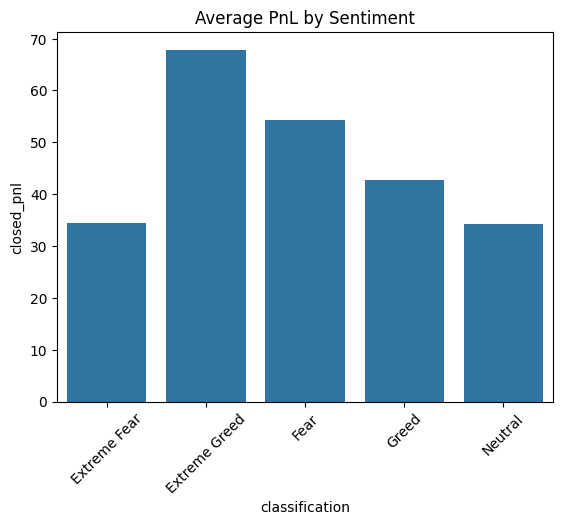

In [99]:
avg_pnl = df.groupby('classification')['closed_pnl'].mean().reset_index()

sns.barplot(x='classification', y='closed_pnl', data=avg_pnl)
plt.xticks(rotation=45)
plt.title("Average PnL by Sentiment")
plt.show()

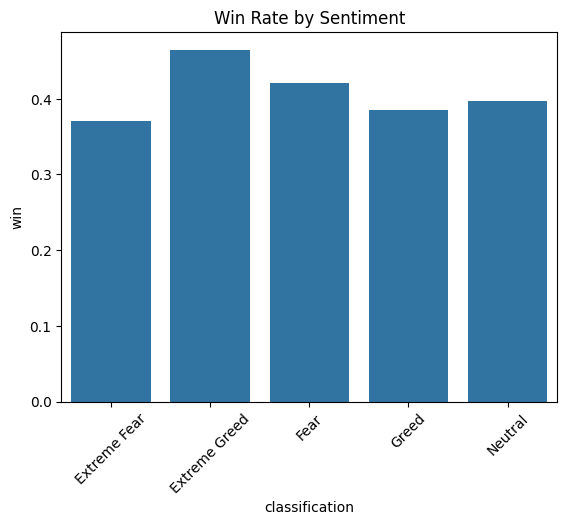

In [100]:
win_rate = df.groupby('classification')['win'].mean().reset_index()

sns.barplot(x='classification', y='win', data=win_rate)
plt.xticks(rotation=45)
plt.title("Win Rate by Sentiment")
plt.show()

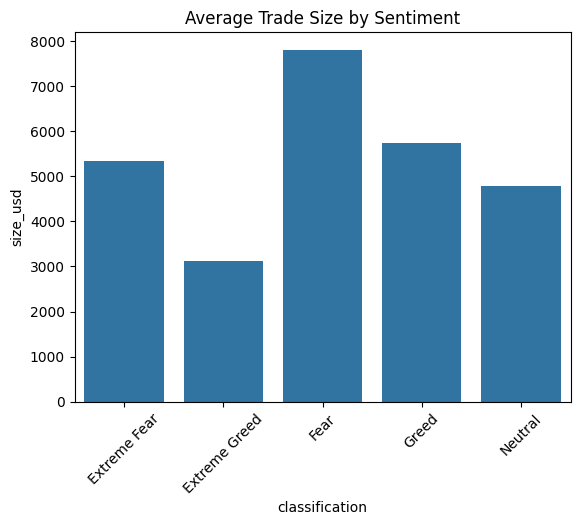

In [101]:
avg_size = df.groupby('classification')['size_usd'].mean().reset_index()

sns.barplot(x='classification', y='size_usd', data=avg_size)
plt.xticks(rotation=45)
plt.title("Average Trade Size by Sentiment")
plt.show()

# Insights

### 1. Performance Improves in Greed Conditions
Traders achieve the highest average PnL and win rate during Extreme Greed periods. This suggests that strong market trends create favorable conditions for profitability.

### 2. Fear Leads to Overtrading and Higher Risk Exposure
During Fear periods, traders execute the highest number of trades and use the largest position sizes, yet their win rate is lower. This indicates reactive or emotional trading behavior.

### 3. Traders Do Not Show Strong Directional Bias
The ratio of BUY and SELL trades remains balanced across all sentiment regimes, indicating that traders are not making strong directional bets based on sentiment.

# Strategy Recommendations

### 1. Reduce Risk During Fear Conditions
Traders should reduce position size and avoid excessive trading during Fear periods, as increased activity does not lead to better performance.

### 2. Use Momentum Strategies During Greed
During Extreme Greed, traders can benefit from trend-following strategies with smaller and consistent position sizes, as market conditions are more predictable.